In [1]:
import requests
import pandas as pd
import time
from tqdm import tqdm

In [8]:
API_KEY = "ec2b89a7-1958-4bba-8d28-32fade8c5b73" 

In [14]:
import requests
import json
import time

# API KEY
API_KEY = API_KEY  

params = {}

# Example gene: APP
params["gene_ncbi_id"] = "351"

# First page
params["page_number"] = "0"

headers = {
    "Authorization": API_KEY,
    "accept": "application/json"
}

response = requests.get(
    "https://api.disgenet.com/api/v1/gda/summary",
    params=params,
    headers=headers,
    verify=False
)

print("Status Code:", response.status_code)

data = json.loads(response.text)

print("STATUS:", data["status"])
print("TOTAL RESULTS:", data["paging"]["totalElements"])
print("RESULTS IN THIS PAGE:", data["paging"]["totalElementsInPage"])

print("\nSample payload:")
print(data["payload"][:3])

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Status Code: 200
STATUS: OK
TOTAL RESULTS: 56
RESULTS IN THIS PAGE: 56

Sample payload:
[{'assocID': 'jm9gkJoBlSU3PyINRMPN', 'symbolOfGene': 'APP', 'geneNcbiID': 351, 'geneEnsemblIDs': ['ENSG00000142192'], 'geneNcbiType': 'protein-coding', 'geneDSI': 0.392, 'geneDPI': 0.957, 'genepLI': 0.99999, 'geneProteinStrIDs': ['P05067'], 'geneProteinClassIDs': ['DTO_05007584'], 'geneProteinClassNames': ['Enzyme modulator'], 'diseaseVocabularies': ['MESH_D000544', 'ICD10_G30', 'ICD10_G30.9', 'NCI_C2866', 'OMIM_104300', 'ICD9CM_331.0', 'OMIM_516000', 'HPO_HP:0002511', 'DO_0110035', 'DO_0110037', 'DO_0110038', 'DO_0110039', 'DO_0110041', 'DO_0110043', 'DO_0110044', 'DO_0110045', 'DO_0110046', 'DO_0110047', 'DO_0110048', 'DO_10652', 'DO_11870', 'MONDO_0004975', 'MONDO_0007089', 'MONDO_0011194', 'MONDO_0012344', 'MONDO_0012609', 'MONDO_0012630', 'MONDO_0012631', 'MONDO_0011561', 'MONDO_0011647', 'MONDO_0011401', 'MONDO_0011777', 'MONDO_0012321', 'UMLS_C0002395'], 'diseaseName': "Alzheimer's Disease", 

In [15]:
import pandas as pd

records = []

for item in data["payload"]:
    
    proteins = item.get("geneProteinStrIDs", [])
    disease = item.get("diseaseName")

    for p in proteins:
        records.append({
            "protein": p,
            "disease": disease
        })

df = pd.DataFrame(records)

print(df.head())
print("Total edges:", len(df))

  protein                      disease
0  P05067          Alzheimer's Disease
1  P05067           Impaired cognition
2  P05067           Nerve Degeneration
3  P05067   familial Alzheimer disease
4  P05067  Neurodegenerative Disorders
Total edges: 56


In [16]:
df.to_csv(
    "../data/interim/protein_disease_edges.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


In [17]:
import pandas as pd

# load drug-protein edges
df_dp = pd.read_csv("../data/interim/drug_protein_edges.csv")

print(df_dp.head())

print("Total rows:", len(df_dp))

   drug_id  drug_name protein_id
0  DB00001  Lepirudin     P00734
1  DB00002  Cetuximab     P00533
2  DB00002  Cetuximab     O75015
3  DB00002  Cetuximab     P02745
4  DB00002  Cetuximab     P02746
Total rows: 26766


In [19]:
proteins = df_dp["protein_id"].unique()

print("Unique proteins:", len(proteins))
print(proteins[:10])

Unique proteins: 5096
['P00734' 'P00533' 'O75015' 'P02745' 'P02746' 'P02747' 'P08637' 'P12314'
 'P12318' 'P24855']


In [20]:
protein_list = proteins.tolist()

print("Total proteins:", len(protein_list))
print(protein_list[:10])

Total proteins: 5096
['P00734', 'P00533', 'O75015', 'P02745', 'P02746', 'P02747', 'P08637', 'P12314', 'P12318', 'P24855']


In [21]:
import requests

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": "accession:P00533",
    "fields": "accession,xref_geneid",
    "format": "json"
}

response = requests.get(url, params=params)

data = response.json()

print(data)

{'results': [{'entryType': 'UniProtKB reviewed (Swiss-Prot)', 'primaryAccession': 'P00533', 'uniProtKBCrossReferences': [{'database': 'GeneID', 'id': '1956', 'properties': [{'key': 'Description', 'value': '-'}]}], 'extraAttributes': {'uniParcId': 'UPI000003E750'}}]}


In [22]:
import requests
import time

def get_gene_id(uniprot_id):
    
    url = "https://rest.uniprot.org/uniprotkb/search"

    params = {
        "query": f"accession:{uniprot_id}",
        "fields": "accession,xref_geneid",
        "format": "json"
    }

    try:
        r = requests.get(url, params=params)
        data = r.json()

        results = data.get("results", [])

        if len(results) > 0:
            refs = results[0].get("uniProtKBCrossReferences", [])

            for ref in refs:
                if ref["database"] == "GeneID":
                    return ref["id"]

    except:
        return None

    return None

In [23]:
print(get_gene_id("P00533"))

1956


In [25]:
mapping = []

for p in proteins[:50]:   # first 50 proteins

    gene_id = get_gene_id(p)

    mapping.append({
        "protein": p,
        "gene_ncbi_id": gene_id
    })

    print(p, gene_id)

    time.sleep(0.2)   # avoid API overload

import pandas as pd

map_df = pd.DataFrame(mapping)

print("\nMapping preview:")
print(map_df.head())

P00734 2147
P00533 1956
O75015 2215
P02745 712
P02746 713
P02747 714
P08637 2214
P12314 2209
P12318 2212
P24855 1773
P01589 3559
P14784 3560
P01375 7124
P01374 4049
P31994 2213
P31995 9103
P30968 2798
P01148 2796
P48551 3455
P17181 3454
P01563 3440
P00747 5340
P02671 2243
P02679 2266
P05121 5054
Q02643 2692
P19235 2057
Q03405 5329
P05120 5055
P00749 5328
P05154 5104
P98164 4036
Q9Y5Y6 6768
P14543 4811
P22888 3973
P30988 799
Q99062 1441
P15509 1438
P26951 3563
P32927 1439
P34741 6383
P16473 7253
P00742 2159
P00740 2158
P04275 7450
O14832 5264
P07307 433
P11021 3309
P27797 811
P27824 821

Mapping preview:
  protein gene_ncbi_id
0  P00734         2147
1  P00533         1956
2  O75015         2215
3  P02745          712
4  P02746          713


In [26]:
map_df.to_csv("../data/interim/protein_gene_mapping.csv", index=False)

print("Mapping saved successfully")

Mapping saved successfully


In [28]:
import requests
import json
import time

def get_disease_associations(gene_id):

    params = {
        "gene_ncbi_id": gene_id,
        "page_number": "0"
    }

    headers = {
        "Authorization": API_KEY,
        "accept": "application/json"
    }

    url = "https://api.disgenet.com/api/v1/gda/summary"

    try:
        response = requests.get(url, params=params, headers=headers, verify=False)
        data = response.json()

        if data["status"] == "OK":
            return data["payload"]
    except:
        return []

    return []

In [29]:
test_gene = map_df["gene_ncbi_id"].iloc[0]

diseases = get_disease_associations(test_gene)

print("Diseases found:", len(diseases))

print(diseases[:2])

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Diseases found: 65
[{'assocID': '4uHqiZoBKfT2TYe7yRUh', 'symbolOfGene': 'F2', 'geneNcbiID': 2147, 'geneEnsemblIDs': ['ENSG00000180210'], 'geneNcbiType': 'protein-coding', 'geneDSI': 0.38, 'geneDPI': 0.913, 'genepLI': None, 'geneProteinStrIDs': ['P00734'], 'geneProteinClassIDs': None, 'geneProteinClassNames': None, 'diseaseVocabularies': ['OMIM_613679', 'NCI_C26799', 'MESH_C562724', 'OMIM_176930', 'ORDO_325', 'DO_2235', 'MONDO_0013361', 'UMLS_C0272317'], 'diseaseName': 'Hereditary factor II deficiency disease', 'diseaseType': '[disease]', 'diseaseUMLSCUI': 'C0272317', 'diseaseClasses_MSH': ['Congenital, Hereditary, and Neonatal Diseases and Abnormalities (C16)', 'Hemic and Lymphatic Diseases (C15)'], 'diseaseClasses_UMLS_ST': ['Disease or Syndrome (T047)'], 'diseaseClasses_DO': ['genetic disease (630)', 'disease of anatomical entity (7)'], 'diseaseClasses_HPO': [], 'disease_prevalence_class': '<1 / 1 000 000', 'disease_prevalence_geo_area': 'Europe', 'disease_prevalence_type': 'Point pr

In [30]:
records = []

for item in diseases:

    proteins = item.get("geneProteinStrIDs", [])
    disease = item.get("diseaseName")

    for p in proteins:
        records.append({
            "protein": p,
            "disease": disease
        })

import pandas as pd

df_test = pd.DataFrame(records)

print(df_test.head())
print("Total edges:", len(df_test))

  protein                                  disease
0  P00734  Hereditary factor II deficiency disease
1  P00734                               Thrombosis
2  P00734                        Venous Thrombosis
3  P00734                            Thrombophilia
4  P00734              Blood Coagulation Disorders
Total edges: 65


In [31]:
records = []

for i, row in map_df.iterrows():

    gene_id = row["gene_ncbi_id"]

    if pd.isna(gene_id):
        continue

    diseases = get_disease_associations(gene_id)

    for item in diseases:

        proteins = item.get("geneProteinStrIDs", [])
        disease = item.get("diseaseName")

        for p in proteins:
            records.append({
                "protein": p,
                "disease": disease
            })

    if i % 10 == 0:
        print("Processed:", i)

    time.sleep(1)  # avoid API limit

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Processed: 0


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 10


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

...

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 30


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 40


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

In [32]:
df_edges = pd.DataFrame(records)

print(df_edges.head())

print("\nTotal edges collected:", len(df_edges))

  protein                                  disease
0  P00734  Hereditary factor II deficiency disease
1  P00734                               Thrombosis
2  P00734                        Venous Thrombosis
3  P00734                            Thrombophilia
4  P00734              Blood Coagulation Disorders

Total edges collected: 1100


In [33]:
df_edges.to_csv(
    "../data/interim/protein_disease_edges.csv",
    index=False
)

print("protein_disease_edges.csv saved successfully")

protein_disease_edges.csv saved successfully


In [34]:
records = []

for i, row in map_df.iterrows():

    gene_id = row["gene_ncbi_id"]

    if pd.isna(gene_id):
        continue

    diseases = get_disease_associations(gene_id)

    for item in diseases:

        proteins = item.get("geneProteinStrIDs", [])
        disease = item.get("diseaseName")

        for p in proteins:
            records.append({
                "protein": p,
                "disease": disease
            })

    if i % 10 == 0:
        print("Processed:", i)

    time.sleep(1)

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Processed: 0


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 10


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

...

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 30


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 40


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

In [35]:
print(len(map_df))

50


In [36]:
mapping = []

for p in proteins:   # IMPORTANT: yaha [:50] nahi hai

    gene_id = get_gene_id(p)

    mapping.append({
        "protein": p,
        "gene_ncbi_id": gene_id
    })

    print(p, gene_id)

    time.sleep(0.2)

map_df = pd.DataFrame(mapping)

print("Total mapped proteins:", len(map_df))

P27824 821
Total mapped proteins: 1


In [37]:
print(len(proteins))
print(proteins[:10])

1
['P27824']


In [38]:
df_dp = pd.read_csv("../data/interim/drug_protein_edges.csv")

proteins = df_dp["protein_id"].unique()

print("Total proteins:", len(proteins))
print(proteins[:10])

Total proteins: 5096
['P00734' 'P00533' 'O75015' 'P02745' 'P02746' 'P02747' 'P08637' 'P12314'
 'P12318' 'P24855']


In [39]:
mapping = []

for i, p in enumerate(proteins):

    gene_id = get_gene_id(p)

    mapping.append({
        "protein": p,
        "gene_ncbi_id": gene_id
    })

    if i % 20 == 0:
        print("Processed:", i)

    time.sleep(0.2)

map_df = pd.DataFrame(mapping)

print("Total mapped proteins:", len(map_df))

Processed: 0
Processed: 20
Processed: 40
Processed: 60
Processed: 80
Processed: 100
Processed: 120
Processed: 140
Processed: 160
Processed: 180
Processed: 200
Processed: 220
Processed: 240
Processed: 260
Processed: 280
Processed: 300
Processed: 320
Processed: 340
Processed: 360
Processed: 380
Processed: 400
Processed: 420
Processed: 440
Processed: 460
Processed: 480
Processed: 500
Processed: 520
Processed: 540
Processed: 560
Processed: 580
Processed: 600
Processed: 620
Processed: 640
Processed: 660
Processed: 680
Processed: 700
Processed: 720
Processed: 740
Processed: 760
Processed: 780
Processed: 800
Processed: 820
Processed: 840
Processed: 860
Processed: 880
Processed: 900
Processed: 920
Processed: 940
Processed: 960
Processed: 980
Processed: 1000
Processed: 1020
Processed: 1040
Processed: 1060
Processed: 1080
Processed: 1100
Processed: 1120
Processed: 1140
Processed: 1160
Processed: 1180
Processed: 1200
Processed: 1220
Processed: 1240
Processed: 1260
Processed: 1280
Processed: 1300


In [40]:
records = []

for i, row in map_df.iterrows():

    gene_id = row["gene_ncbi_id"]

    if pd.isna(gene_id):
        continue

    diseases = get_disease_associations(gene_id)

    for item in diseases:

        proteins = item.get("geneProteinStrIDs", [])
        disease = item.get("diseaseName")

        for p in proteins:
            records.append({
                "protein": p,
                "disease": disease
            })

    if i % 20 == 0:
        print("Processed:", i)

    time.sleep(1)

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Processed: 0


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 20


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

...

Processed: 560


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 580


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

TypeError: 'NoneType' object is not iterable

In [41]:
start_index = 581 

for i, row in map_df.iloc[start_index:].iterrows():

    gene_id = row["gene_ncbi_id"]

    if pd.isna(gene_id):
        continue

    diseases = get_disease_associations(gene_id)

    for item in diseases:

        proteins = item.get("geneProteinStrIDs")

        if proteins is None:
            continue

        disease = item.get("diseaseName")

        for p in proteins:
            records.append({
                "protein": p,
                "disease": disease
            })

    if i % 20 == 0:
        print("Processed:", i)

    time.sleep(1)

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 600


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 620


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

...

C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 5040


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

Processed: 5060


C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Srija Paul Chowdhury\.conda\envs\drug_gnn\lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.disgenet.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-war

In [42]:
df_edges = pd.DataFrame(records)

print("Total edges collected:", len(df_edges))

Total edges collected: 38959


In [43]:
df_edges.to_csv("../data/interim/protein_disease_edges.csv", index=False)

In [44]:
print(df_edges.head())
print("Unique proteins:", df_edges["protein"].nunique())
print("Unique diseases:", df_edges["disease"].nunique())

  protein                                  disease
0  P00734  Hereditary factor II deficiency disease
1  P00734                               Thrombosis
2  P00734                        Venous Thrombosis
3  P00734                            Thrombophilia
4  P00734              Blood Coagulation Disorders
Unique proteins: 2682
Unique diseases: 7687


In [45]:
import os
print(os.path.exists("../data/interim/protein_disease_edges.csv"))

True


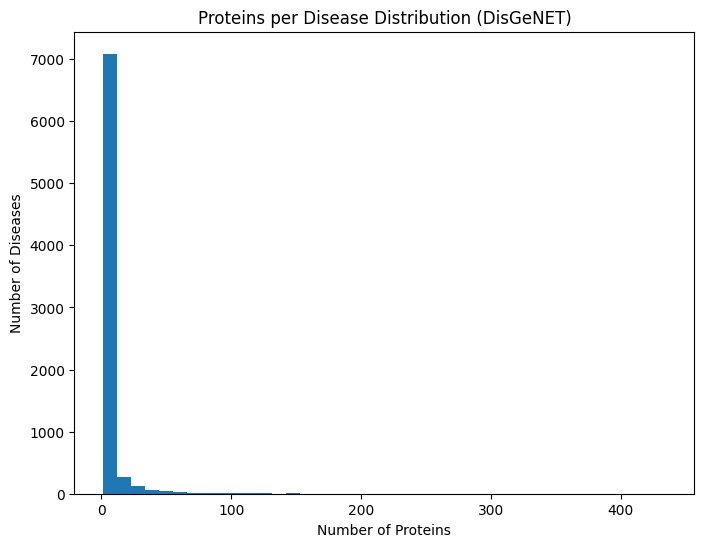

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
protein_disease = pd.read_csv("../data/interim/protein_disease_edges.csv")

# count proteins per disease
proteins_per_disease = protein_disease.groupby("disease")["protein"].nunique()

plt.figure(figsize=(8,6))

plt.hist(proteins_per_disease, bins=40)

plt.title("Proteins per Disease Distribution (DisGeNET)")
plt.xlabel("Number of Proteins")
plt.ylabel("Number of Diseases")

plt.show()